In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Illustration of Brownian motion. Show that it has no drift and increasing variance, so the longer the time intervals, the wider possible spreads.

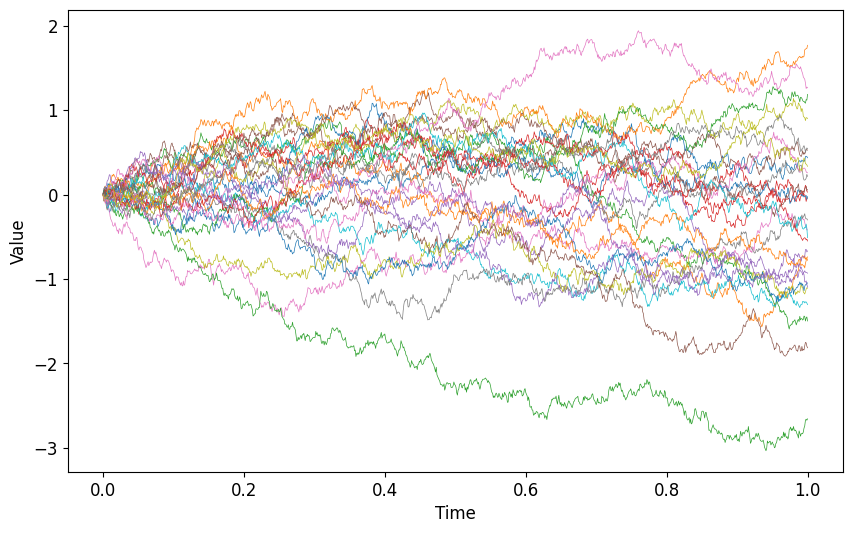

In [14]:
def sim_BM(T, Ndt, Nsims=10):
        
    # time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for the RW
    W = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    W[0,:] = 0
    
    # recursively simulate the process ( W[idx,:] is (1 , Nsims) )
    for i in range(Ndt):
        Z = np.random.normal(0,1,Nsims)
        W[i+1,:] = W[i,:] + np.sqrt(dt) * Z
    return time, W

#Parameters
T=1
Ndt = 1000
Npaths=100

#Seed
np.random.seed(123)

#Simulate
t, W = sim_BM(T,Ndt,Npaths)
   
# plot the sample paths
plt.figure(figsize=(10, 6))
plt.plot(t, W[:,1:30], linewidth=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

Illustration of geometric Brownian motion with different parameter values.

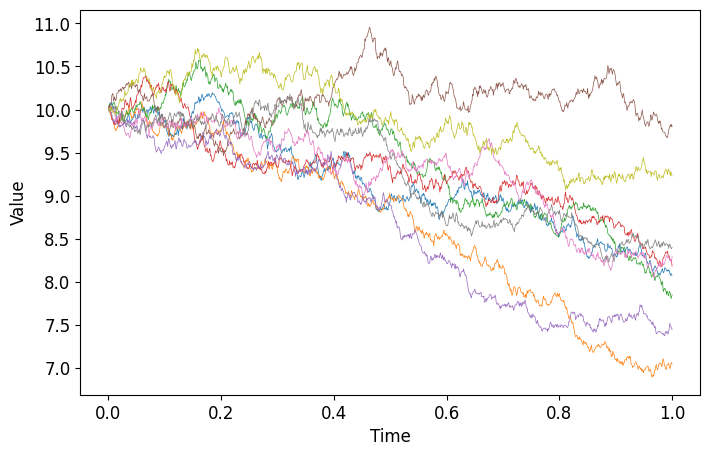

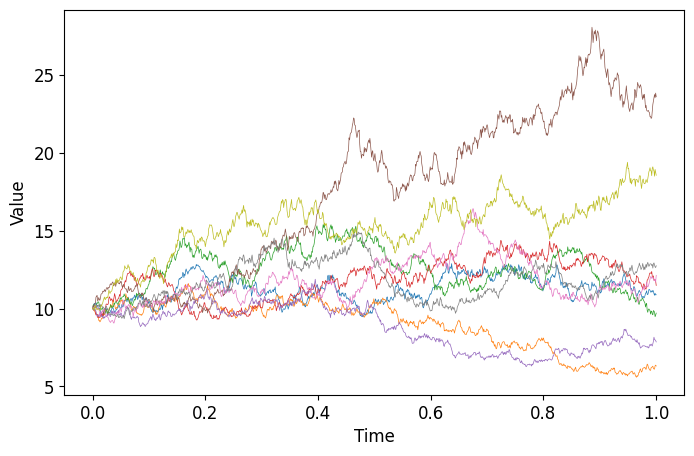

In [4]:
#Parameters
X0 = 10
mu1 = -0.2
mu2=0.2
sigma1 = 0.1
sigma2=0.4
T = 1
Ndt = 1000
Nsims = 500

def simulate_GBM(X0, mu, sigma, T, Ndt, Nsims=10):
    # create time increment
    dt = T / Ndt
    
    # set the different times as a vector
    time = np.linspace(0, T, Ndt+1)
    
    # initialize the matrix for GBMs
    X = np.zeros((Ndt+1,Nsims))
    
    # initial value of the process
    X[0,:] = X0
    
    # recursively simulate the process ( S[idx,:] is (1 , Nsims) )
    for idx in range(Ndt):
        Z = np.random.randn(Nsims)
        # or Z = np.random.normal(0.0, 1.0, size=(1,Nsims))
        X[idx+1,:] = X[idx,:] * np.exp( (mu - (sigma**2)/2) * dt
                                      + sigma * np.sqrt(dt) * Z)
    
    return time, X

np.random.seed(42)
t1, X1 = simulate_GBM(X0, mu1, sigma1, T, Ndt, Nsims)

np.random.seed(42)
t2, X2 = simulate_GBM(X0, mu2, sigma2, T, Ndt, Nsims)


plt.figure(figsize=(8, 5))
plt.plot(t1, X1[:,1:10], linewidth=0.5)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(t2, X2[:,1:10], linewidth=0.5)
plt.xlabel('Time',fontsize=12)
plt.ylabel('Value',fontsize=12)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


Recreation of Table 1 in Jiao and Liu.

In [15]:
# Parameters
T = 5
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2_values = [0.005, 0.01]

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

# mu depending on ESG rating
def mu_G(G):
    G1, G2 = G

    # Asset 1
    if G1 == 1.0:
        mu1 = 0.12
    elif G1 == 0.5:
        mu1 = 0.08
    
    # Asset 2
    if G2 == -0.5:
        mu2 = 0.22
    elif G2 == -1.0:
        mu2 = 0.27

    return np.array([mu1, mu2])


# Panels A-D
panels = {
    "Panel A: G1=1, G2=-0.5": np.array([1.0, -0.5]),
    "Panel B: G1=1, G2=-1": np.array([1.0, -1.0]),
    "Panel C: G1=0.5, G2=-0.5": np.array([0.5, -0.5]),
    "Panel D: G1=0.5, G2=-1": np.array([0.5, -1.0]),
}

all_tables = {}

for panel_name, G in panels.items():
    mu = mu_G(G)
    theta = mu - r * np.ones(2)

    # Merton component
    pi_Merton = (1 / (gamma1 * X0)) * np.exp(-r * T) * (Sigma_inv @ theta)

    rows = []

    # Brown investor
    for i in range(2):
        rows.append({
            "Investor": "Brown investor",
            "Asset": f"Asset {i+1}",
            "Merton": pi_Merton[i],
            "ESG": np.nan,
            "Combined": pi_Merton[i]
        })

    # Green investors
    for gamma2 in gamma2_values:
        pi_ESG = (
            gamma2 / (gamma1**2 * X0)
            * np.exp(-r * T)
            * (Sigma_inv @ G)
        )
        pi_green = pi_Merton + pi_ESG

        for i in range(2):
            rows.append({
                "Investor": f"Green investor, gamma2={gamma2}",
                "Asset": f"Asset {i+1}",
                "Merton": pi_Merton[i],
                "ESG": pi_ESG[i],
                "Combined": pi_green[i]
            })

    all_tables[panel_name] = pd.DataFrame(rows)

# Print results
for panel_name, df in all_tables.items():
    print("\n" + panel_name)
    print(df.round(4).to_string(index=False))



Panel A: G1=1, G2=-0.5
                    Investor   Asset  Merton     ESG  Combined
              Brown investor Asset 1  0.5715     NaN    0.5715
              Brown investor Asset 2  0.1248     NaN    0.1248
Green investor, gamma2=0.005 Asset 1  0.5715  0.0688    0.6403
Green investor, gamma2=0.005 Asset 2  0.1248 -0.0058    0.1190
 Green investor, gamma2=0.01 Asset 1  0.5715  0.1376    0.7091
 Green investor, gamma2=0.01 Asset 2  0.1248 -0.0116    0.1132

Panel B: G1=1, G2=-1
                    Investor   Asset  Merton     ESG  Combined
              Brown investor Asset 1  0.5613     NaN    0.5613
              Brown investor Asset 2  0.1625     NaN    0.1625
Green investor, gamma2=0.005 Asset 1  0.5613  0.0698    0.6311
Green investor, gamma2=0.005 Asset 2  0.1625 -0.0096    0.1529
 Green investor, gamma2=0.01 Asset 1  0.5613  0.1397    0.7010
 Green investor, gamma2=0.01 Asset 2  0.1625 -0.0191    0.1433

Panel C: G1=0.5, G2=-0.5
                    Investor   Asset  Merton  

We study the effect of gamma_2

In [11]:
# Values of gamma_2
gamma2_values = [0, 0.01, 0.05, 0.1,0.5]

# ESG scenario
G = np.array([1.0, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

rows = []

for gamma2 in gamma2_values:
    # Merton component
    Merton = (1 / gamma1) * np.exp(-r * T) * (Sigma_inv @ theta)
    
    # ESG component
    ESG_component = (gamma2 / gamma1**2) * np.exp(-r * T) * (Sigma_inv @ G)
    
    # combined green strategy
    green_strategy = Merton + ESG_component
    
    rows.append({
        r"$\gamma_2$": gamma2,
        r"Merton asset 1": Merton[0],
        r"Merton asset 2": Merton[1],
        r"ESG asset 1": ESG_component[0],
        r"ESG asset 2": ESG_component[1],
        r"$u_1^{g,*}(0)$": green_strategy[0],
        r"$u_2^{g,*}(0)$": green_strategy[1]
    })

gamma2_table = pd.DataFrame(rows)
gamma2_table = gamma2_table.round(4)


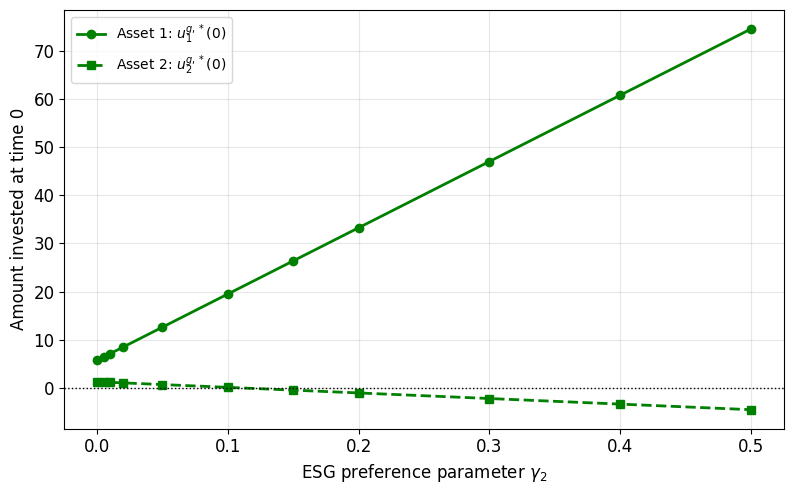

In [7]:
# gamma_2 values
gamma2_values = np.array([
    0.00, 0.005, 0.01, 0.02, 0.05,
    0.10, 0.15, 0.20, 0.30, 0.40, 0.50
])

# Parameters
T = 5
r = 0.03
X0 = 10
gamma1 = 0.5

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

G = np.array([1.0, -0.5]) 

mu = mu_G(G)
theta = mu - r * np.ones(2)

u1_values = []
u2_values = []

for gamma2_value in gamma2_values:
    u_g0 = (
        (1 / gamma1) * np.exp(-r * T) * (Sigma_inv @ theta)
        + (gamma2_value / gamma1**2) * np.exp(-r * T) * (Sigma_inv @ G)
    )
    
    u1_values.append(u_g0[0])
    u2_values.append(u_g0[1])

plt.figure(figsize=(8, 5))
plt.plot(gamma2_values,u1_values,marker="o",label=r"Asset 1: $u_1^{g,*}(0)$",color="green",linewidth=2)
plt.plot(gamma2_values,u2_values,marker="s",label=r"Asset 2: $u_2^{g,*}(0)$",color="green",linewidth=2, linestyle="--")

plt.axhline(0, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"ESG preference parameter $\gamma_2$", fontsize=12)
plt.ylabel("Amount invested at time 0",fontsize=12)
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.legend()
plt.show()

We study the effect of gamma_1

In [16]:
# Parameters
T = 5
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2=0.01

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)

G = np.array([1.0, -0.5]) 

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

gamma1_values = np.array([0.1,0.25, 0.5, 0.75, 1.0, 1.5, 2.0])

rows = []

for gamma1_value in gamma1_values:
    u_M = (
        (1 / gamma1_value)
        * np.exp(-r * T)
        * (Sigma_inv @ theta)
    )
    
    u_ESG = (
        (gamma2 / gamma1_value**2)
        * np.exp(-r * T)
        * (Sigma_inv @ G)
    )
    
    u_g = u_M + u_ESG
    
    rows.append({
        r"$\gamma_1$": gamma1_value,
        r"$u_1^M$": u_M[0],
        r"$u_1^{ESG}$": u_ESG[0],
        r"$u_1^{g,*}(0)$": u_g[0],
        r"$u_2^M$": u_M[1],
        r"$u_2^{ESG}$": u_ESG[1],
        r"$u_2^{g,*}(0)$": u_g[1],
    })

gamma1_table = pd.DataFrame(rows)
gamma1_table.round(4)

,$\gamma_1$,$u_1^M$,$u_1^{ESG}$,"$u_1^{g,*}(0)$",$u_2^M$,$u_2^{ESG}$,"$u_2^{g,*}(0)$"
0,0.10,28.5743,34.4044,62.9787,6.2406,-2.9000,3.3406
1,0.25,11.4297,5.5047,16.9344,2.4962,-0.4640,2.0323
2,0.50,5.7149,1.3762,7.0910,1.2481,-0.1160,1.1321
3,0.75,3.8099,0.6116,4.4215,0.8321,-0.0516,0.7805
4,1.00,2.8574,0.3440,3.2015,0.6241,-0.0290,0.5951
5,1.50,1.9050,0.1529,2.0579,0.4160,-0.0129,0.4032
6,2.00,1.4287,0.0860,1.5147,0.3120,-0.0072,0.3048


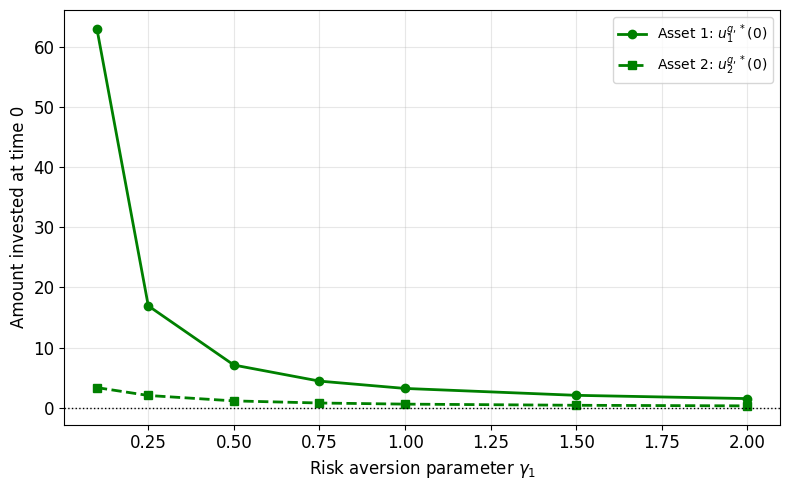

In [17]:
u1_values = []
u2_values = []

for gamma1_value in gamma1_values:
    u_g0 = (
        (1 / gamma1_value)
        * np.exp(-r * T)
        * (Sigma_inv @ theta)
        + (gamma2 / gamma1_value**2)
        * np.exp(-r * T)
        * (Sigma_inv @ G)
    )
    
    u1_values.append(u_g0[0])
    u2_values.append(u_g0[1])

plt.figure(figsize=(8, 5))

plt.plot(
    gamma1_values,
    u1_values,
    marker="o",
    label=r"Asset 1: $u_1^{g,*}(0)$",
    color="green",
    linewidth=2
)

plt.plot(
    gamma1_values,
    u2_values,
    marker="s",
    label=r"Asset 2: $u_2^{g,*}(0)$",
    color="green",
    linewidth=2,
    linestyle="--"
)

plt.axhline(0, color="black", linestyle=":", linewidth=1)

plt.xlabel(r"Risk aversion parameter $\gamma_1$", fontsize=12)
plt.ylabel("Amount invested at time 0", fontsize=12)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

Simulated wealth paths for brown and green investor. First we use the calibrated parameter values from Jiao and Liu.

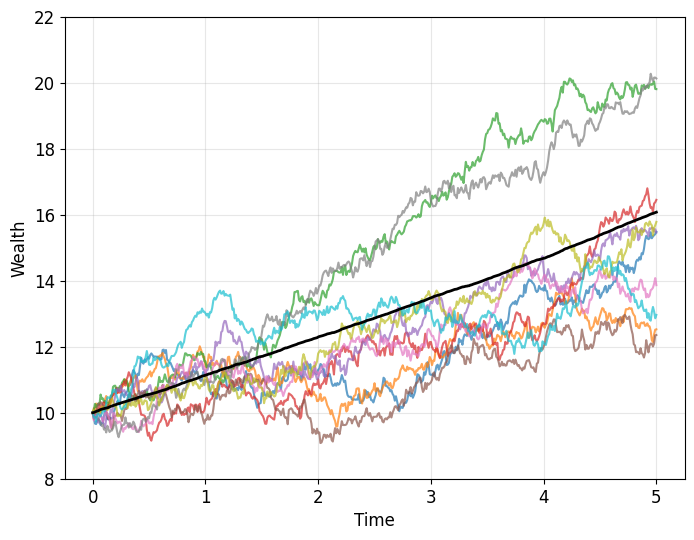

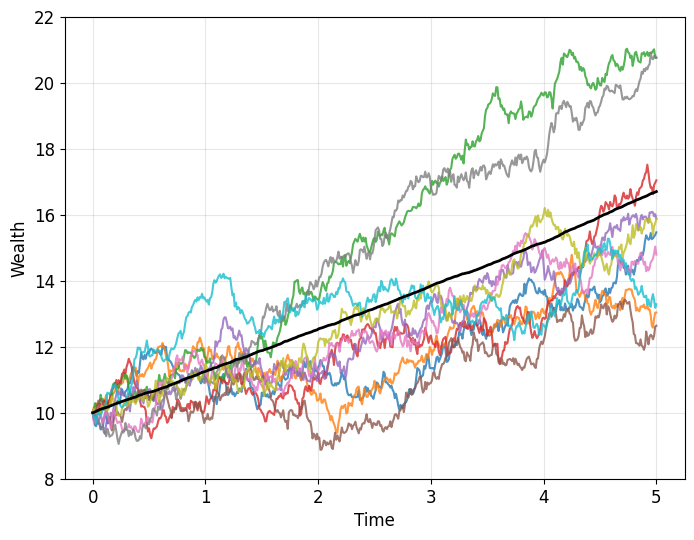

In [18]:
def simulate_wealth(X0,mu,sigma,gamma1,gamma2,Sigma,G,r,theta, T,Ndt,Nsims=100):
    dt=T/Ndt
    time = np.linspace(0,T,Ndt+1)

    X_b=np.zeros((Ndt+1,Nsims))
    X_g=np.zeros((Ndt+1,Nsims))

    X_b[0,:]=X0
    X_g[0,:]=X0

    Sigma_inv=np.linalg.inv(Sigma)


    for idx in range(Ndt):
        t=time[idx]

        #Optimal amount for brown investor
        u_b=(1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta

        #Optimal amount for green investor
        u_g=((1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta+(gamma2/gamma1**2)*np.exp(-r*(T-t))*Sigma_inv@G)

        Z=np.random.randn(2,Nsims)
        dW=np.sqrt(dt)*Z

        #Euler discretization
        X_b[idx+1,:]=(X_b[idx,:]+(r*X_b[idx,:]+u_b.T@theta)*dt+(u_b.T@sigma@dW))
        X_g[idx+1,:]=(X_g[idx,:]+(r*X_g[idx,:]+u_g.T@theta)*dt+(u_g.T@sigma@dW))

    return time, X_b,X_g


# Parameters
T = 5
Ndt=500
Nsims=1000
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2=0.01

G = np.array([1, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.48
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)
np.random.seed(123)
time, X_b, X_g=simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    mu=mu,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2,
    Ndt=Ndt,
    Nsims=Nsims
)

#Brown investor
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(time, X_b[:, i], alpha=0.7)

plt.xlabel("Time",fontsize=12)
plt.ylabel("Wealth",fontsize=12)
plt.plot(time, np.mean(X_b, axis=1), linewidth=2, color='black')
plt.grid(True, alpha=0.3)
plt.ylim(8, 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()


#Green investor
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(time, X_g[:, i], alpha=0.8)

plt.plot(time, np.mean(X_g, axis=1), linewidth=2, color='black')
plt.xlabel("Time",fontsize=12)
plt.ylabel("Wealth",fontsize=12)
plt.grid(True, alpha=0.3)
plt.ylim(8, 22)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.show()

We now try to simulate the same, but with alternative values for gamma_2 and sigma_2.

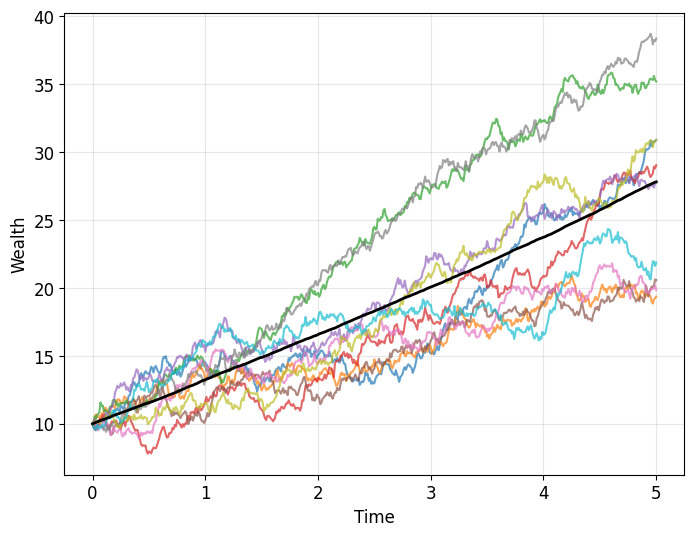

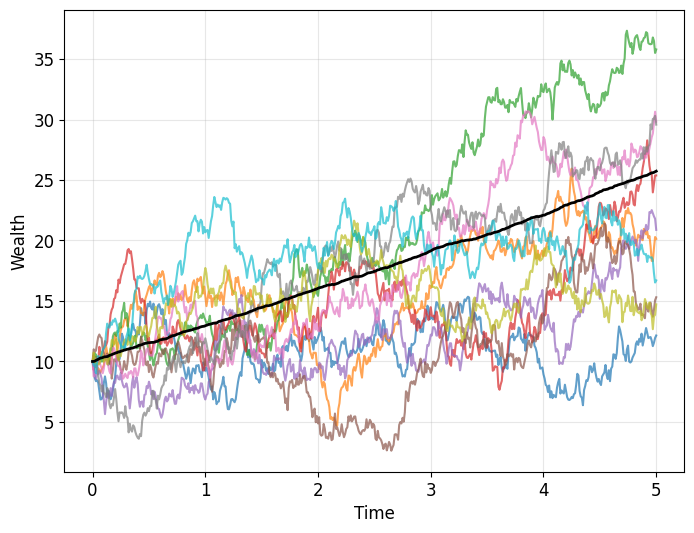

In [19]:
def simulate_wealth(X0,mu,sigma,gamma1,gamma2,Sigma,G,r,theta, T,Ndt,Nsims=100):
    dt=T/Ndt
    time = np.linspace(0,T,Ndt+1)

    X_b=np.zeros((Ndt+1,Nsims))
    X_g=np.zeros((Ndt+1,Nsims))

    X_b[0,:]=X0
    X_g[0,:]=X0

    Sigma_inv=np.linalg.inv(Sigma)


    for idx in range(Ndt):
        t=time[idx]

        #Optimal amount for brown investor
        u_b=(1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta

        #Optimal amount for green investor
        u_g=((1/gamma1)*np.exp(-r*(T-t))*Sigma_inv@theta+(gamma2/gamma1**2)*np.exp(-r*(T-t))*Sigma_inv@G)

        Z=np.random.randn(2,Nsims)
        dW=np.sqrt(dt)*Z

        #Euler discretization
        X_b[idx+1,:]=(X_b[idx,:]+(r*X_b[idx,:]+u_b.T@theta)*dt+(u_b.T@sigma@dW))
        X_g[idx+1,:]=(X_g[idx,:]+(r*X_g[idx,:]+u_g.T@theta)*dt+(u_g.T@sigma@dW))

    return time, X_b,X_g


# Parameters
T = 5
Ndt=500
Nsims=1000
r = 0.03
X0 = 10
gamma1 = 0.5
gamma2=0.2

G = np.array([1, -0.5])

mu = np.array([0.12, 0.22])
theta = mu - r * np.ones(2)

# Volatility parameters
sigma1 = 0.16
sigma2 = 0.16
rho = 0.09

sigma = np.array([
    [sigma1, 0.0],
    [sigma2 * rho, sigma2 * np.sqrt(1 - rho**2)]
])

Sigma = sigma @ sigma.T
Sigma_inv = np.linalg.inv(Sigma)
np.random.seed(123)
time, X_b, X_g=simulate_wealth(
    X0=X0,
    r=r,
    T=T,
    mu=mu,
    theta=theta,
    sigma=sigma,
    Sigma=Sigma,
    G=G,
    gamma1=gamma1,
    gamma2=gamma2,
    Ndt=Ndt,
    Nsims=Nsims
)

#Brown investor
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(time, X_b[:, i], alpha=0.7)

plt.xlabel("Time",fontsize=12)
plt.ylabel("Wealth",fontsize=12)
plt.plot(time, np.mean(X_b, axis=1), linewidth=2, color='black')
plt.grid(True, alpha=0.3)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig("Wealth_Brown.pdf", bbox_inches="tight")
plt.show()

#Green investor
plt.figure(figsize=(8, 6))
for i in range(10):
    plt.plot(time, X_g[:, i], alpha=0.7)

plt.plot(time, np.mean(X_g, axis=1), linewidth=2, color='black')
plt.xlabel("Time",fontsize=12)
plt.ylabel("Wealth",fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.savefig("Wealth_Green.pdf", bbox_inches="tight")
plt.show()